# 8) Model Benchmarking & Results

**Siemens Advanta BC — Revenue Forecasting**  
*NOVA IMS | MSc Data Science & Advanced Analytics | 2025–26*

---

This notebook consolidates all forecasting approaches explored across notebooks 6a–6d into a single,
self-contained reference for model performance evaluation.

**Experimental setup:**
| | |
|---|---|
| Train | Periods 1–36 |
| Validation | Periods 37–42 |
| Test (blind) | Periods 43–48 |
| Target | Revenue cons. (anon) |
| Series | 134 TGL Business Subsegments |
| Horizon | 6 periods ahead |
| Primary metrics | RMSE, MAE, wMAPE, R² |


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 20)

APPROACH_COLORS = {
    "TS Baselines":         "#0F766E",
    "ML Recursive":         "#1D4ED8",
    "ML Direct Multi-Step": "#7C3AED",
    "Foundation Models":    "#B45309",
    "Walk-Forward CV":      "#065F46",
}
WINNER_COLOR = "#F59E0B"

print("✓ Imports OK")


✓ Imports OK


---
## 1. Data — All Model Results

Results are copied directly from notebook outputs (validation set, periods 37–42).
Each approach section contains results broken down **by hierarchical level**
(Subsegment → Segment → BU) where available.


In [18]:
# ── 6a: TS Baselines ─────────────────────────────────────────────────────────
# All TS models operate on the raw series — no engineered features.
# Level is effectively "Subsegment" (one model per series).
df_baselines = pd.DataFrame([
    {"Model": "Moving Avg (6)",      "RMSE":  9_709_532, "MAE": 4_588_482, "wMAPE": 12.0, "R2": 0.9796, "Winner": True},
    {"Model": "Moving Avg (3)",      "RMSE": 11_403_219, "MAE": 5_406_896, "wMAPE": 14.1, "R2": 0.9719},
    {"Model": "Prophet",             "RMSE": 12_154_381, "MAE": 5_770_040, "wMAPE": 14.9, "R2": 0.9683},
    {"Model": "Seasonal Naïve",      "RMSE": 12_800_528, "MAE": 5_346_114, "wMAPE": 14.0, "R2": 0.9645},
    {"Model": "ETS (Holt-Winters)",  "RMSE": 14_377_822, "MAE": 6_289_845, "wMAPE": 16.4, "R2": 0.9553},
    {"Model": "SARIMA",              "RMSE": 14_774_150, "MAE": 5_923_012, "wMAPE": 15.3, "R2": 0.9538},
    {"Model": "VAR",                 "RMSE": 16_254_747, "MAE": 7_348_745, "wMAPE": 16.2, "R2": 0.9493},
    {"Model": "Naïve",               "RMSE": 20_881_478, "MAE": 9_968_088, "wMAPE": 26.0, "R2": 0.9056},
]).fillna({"Winner": False})

# ── 6a: ML Recursive — by level ──────────────────────────────────────────────
df_recursive = pd.DataFrame([
    # Subsegment
    {"Model": "Random Forest",     "Level": "Subsegment", "RMSE": 12_920_387,      "MAE":  7_235_794, "wMAPE": 19.8, "R2": 0.9625, "Winner": True},
    {"Model": "LightGBM",          "Level": "Subsegment", "RMSE": 13_847_374,      "MAE":  8_934_442, "wMAPE": 24.5, "R2": 0.9569},
    {"Model": "XGBoost",           "Level": "Subsegment", "RMSE": 25_332_555,      "MAE": 22_247_216, "wMAPE": 60.9, "R2": 0.8559},
    {"Model": "Gradient Boosting", "Level": "Subsegment", "RMSE": 25_402_657,      "MAE": 21_278_919, "wMAPE": 58.3, "R2": 0.8551},

    {"Model": "Ridge",             "Level": "Subsegment", "RMSE": 1_977_049_782,            "MAE": 1_952_121_726,       "wMAPE": 5346.1, "R2": None,   "Note": "Collapsed (wMAPE > 5000%)"},
    {"Model": "Lasso",             "Level": "Subsegment", "RMSE": 1_977_065_405,            "MAE": 1_952_136_597,       "wMAPE": 5346.1, "R2": None,   "Note": "Collapsed"},
    {"Model": "ElasticNet",        "Level": "Subsegment", "RMSE": 1_977_146_095,            "MAE": 1_952_191_943,       "wMAPE": 5346.3, "R2": None,   "Note": "Collapsed"},
    # Segment
    {"Model": "XGBoost",           "Level": "Segment",    "RMSE": 36_513_280,      "MAE": 20_652_000, "wMAPE":  8.2, "R2": 0.9879},
    {"Model": "Gradient Boosting", "Level": "Segment",    "RMSE": 44_076_845,      "MAE": 23_389_626, "wMAPE":  9.2, "R2": 0.9824},
    {"Model": "Lasso",             "Level": "Segment",    "RMSE": 44_473_927,      "MAE": 25_213_573, "wMAPE": 10.0, "R2": 0.9821},
    {"Model": "LightGBM",          "Level": "Segment",    "RMSE": 48_201_518,      "MAE": 22_096_562, "wMAPE":  8.7, "R2": 0.9790},
    {"Model": "Ridge",             "Level": "Segment",    "RMSE": 50_910_221,      "MAE": 28_969_801, "wMAPE": 11.4, "R2": 0.9765},
    {"Model": "ElasticNet",        "Level": "Segment",    "RMSE": 56_008_064,      "MAE": 29_060_447, "wMAPE": 11.5, "R2": 0.9716},
    {"Model": "Random Forest",     "Level": "Segment",    "RMSE": 65_257_949,      "MAE": 29_486_363, "wMAPE": 11.6, "R2": 0.9614},
    # BU
    # BU
    {"Model": "Lasso",             "Level": "BU", "RMSE":  87_582_300, "MAE":  70_286_400, "wMAPE":  6.938652, "R2": 0.974964},
    {"Model": "LightGBM",          "Level": "BU", "RMSE":  91_523_050, "MAE":  65_737_090, "wMAPE":  6.489545, "R2": 0.972661},
    {"Model": "XGBoost",           "Level": "BU", "RMSE":  97_587_630, "MAE":  73_132_880, "wMAPE":  7.219655, "R2": 0.968918},
    {"Model": "Ridge",             "Level": "BU", "RMSE":  98_203_320, "MAE":  76_586_630, "wMAPE":  7.560608, "R2": 0.968524},
    {"Model": "Gradient Boosting", "Level": "BU", "RMSE": 100_939_300, "MAE":  74_009_040, "wMAPE":  7.306149, "R2": 0.966746},
    {"Model": "CatBoost",          "Level": "BU", "RMSE": 104_374_000, "MAE":  69_576_780, "wMAPE":  6.868598, "R2": 0.964444},
    {"Model": "Random Forest",     "Level": "BU", "RMSE": 160_465_100, "MAE": 102_917_100, "wMAPE": 10.159940, "R2": 0.915960},
    {"Model": "ElasticNet",        "Level": "BU", "RMSE": 164_552_600, "MAE": 114_345_500, "wMAPE": 11.288150, "R2": 0.911624},
]).fillna({"Winner": False})

# ── 6b: ML Direct Multi-Step — by level ──────────────────────────────────────
df_direct = pd.DataFrame([
    # Subsegment
    {"Model": "CatBoost",      "Level": "Subsegment", "RMSE":  10_270_056, "MAE":  5_446_644, "wMAPE": 14.08, "R2": 0.9773, "Winner": True},
    {"Model": "XGBoost",       "Level": "Subsegment", "RMSE":  11_327_380, "MAE":  5_175_391, "wMAPE": 13.38, "R2": 0.9724},
    {"Model": "XGBoost (Optuna)", "Level": "Subsegment", "RMSE": 10_739_067, "MAE": None, "wMAPE": 12.68, "R2": 0.9752},
    {"Model": "Ridge (Linear)","Level": "Subsegment", "RMSE":  11_395_822, "MAE":  6_944_689, "wMAPE": 17.95, "R2": 0.9721},
    {"Model": "LightGBM",      "Level": "Subsegment", "RMSE":  12_101_632, "MAE":  5_254_137, "wMAPE": 13.58, "R2": 0.9685},
    {"Model": "Random Forest", "Level": "Subsegment", "RMSE":  13_625_487, "MAE":  5_983_083, "wMAPE": 15.47, "R2": 0.9601},
    # Segment
    {"Model": "XGBoost",       "Level": "Segment",    "RMSE":  49_490_236, "MAE": 24_165_045, "wMAPE":  9.54, "R2": 0.9778},
    {"Model": "LightGBM",      "Level": "Segment",    "RMSE":  49_838_032, "MAE": 24_154_514, "wMAPE":  9.54, "R2": 0.9775},
    {"Model": "Random Forest", "Level": "Segment",    "RMSE":  55_322_294, "MAE": 27_585_774, "wMAPE": 10.89, "R2": 0.9723},
    {"Model": "CatBoost",      "Level": "Segment",    "RMSE":  56_108_305, "MAE": 32_878_876, "wMAPE": 12.98, "R2": 0.9715},
    {"Model": "Ridge (Linear)","Level": "Segment",    "RMSE":  51_675_486, "MAE": 34_826_621, "wMAPE": 13.75, "R2": 0.9758},
    # BU
    {"Model": "Random Forest", "Level": "BU",         "RMSE": 120_543_173, "MAE": 85_704_644, "wMAPE":  8.46, "R2": 0.9526},
    {"Model": "Ridge (Linear)","Level": "BU",         "RMSE": 129_282_233, "MAE": 98_402_795, "wMAPE":  9.71, "R2": 0.9455},
    {"Model": "XGBoost",       "Level": "BU",         "RMSE": 155_083_340, "MAE":122_453_530, "wMAPE": 12.09, "R2": 0.9215},
    {"Model": "LightGBM",      "Level": "BU",         "RMSE": 155_727_667, "MAE":124_084_803, "wMAPE": 12.25, "R2": 0.9209},
    {"Model": "CatBoost",      "Level": "BU",         "RMSE": 159_241_386, "MAE":134_501_480, "wMAPE": 13.28, "R2": 0.9172},
]).fillna({"Winner": False})

# ── 6c: Foundation Models ────────────────────────────────────────────────────
df_pretrained = pd.DataFrame([
    {"Model": "FlowState-r1.1", "RMSE": 7_743_554, "MAE": 3_663_463, "wMAPE":  9.4, "R2": 0.9871, "Winner": True},
    {"Model": "Chronos-2", "RMSE": 8_349_869, "MAE": 3_849_745, "wMAPE": 9.9, "R2": 0.9850},
    {"Model": "TimesFM-2.5",    "RMSE": 9_182_431, "MAE": 4_441_428, "wMAPE": 11.4, "R2": 0.9819},
]).fillna({"Winner": False})


# ── 6d: Walk-Forward CV — by level ───────────────────────────────────────────
df_wf = pd.DataFrame([
    # Subsegment
    {"Model": "XGBoost",           "Level": "Subsegment", "RMSE":  7_405_830, "MAE":  3_634_914, "wMAPE": 10.7, "R2": 0.9866, "Winner": True},
    {"Model": "LightGBM",          "Level": "Subsegment", "RMSE":  7_650_552, "MAE":  3_479_706, "wMAPE": 10.3, "R2": 0.9855},
    {"Model": "Gradient Boosting", "Level": "Subsegment", "RMSE":  9_118_630, "MAE":  4_673_275, "wMAPE": 13.8, "R2": 0.9797},
    {"Model": "Random Forest",     "Level": "Subsegment", "RMSE":  9_552_808, "MAE":  4_517_812, "wMAPE": 13.4, "R2": 0.9774},
    {"Model": "Ridge",             "Level": "Subsegment", "RMSE": 10_149_099, "MAE":  6_204_958, "wMAPE": 18.3, "R2": 0.9753},
    {"Model": "Lasso",             "Level": "Subsegment", "RMSE": 10_172_420, "MAE":  6_398_722, "wMAPE": 18.9, "R2": 0.9752},
    {"Model": "ElasticNet",        "Level": "Subsegment", "RMSE": 25_845_811, "MAE": 15_578_352, "wMAPE": 45.6, "R2": 0.8418},
    # Segment
    {"Model": "XGBoost",           "Level": "Segment",    "RMSE": 26_351_418, "MAE": 12_791_378, "wMAPE":  6.3, "R2": 0.9921},
    {"Model": "Gradient Boosting", "Level": "Segment",    "RMSE": 29_500_780, "MAE": 16_366_588, "wMAPE":  8.0, "R2": 0.9899},
    {"Model": "LightGBM",          "Level": "Segment",    "RMSE": 29_939_074, "MAE": 14_325_608, "wMAPE":  7.0, "R2": 0.9893},
    {"Model": "Ridge",             "Level": "Segment",    "RMSE": 39_312_172, "MAE": 23_044_018, "wMAPE": 11.3, "R2": 0.9822},
    {"Model": "Lasso",             "Level": "Segment",    "RMSE": 39_364_003, "MAE": 22_825_999, "wMAPE": 11.2, "R2": 0.9824},
    {"Model": "Random Forest",     "Level": "Segment",    "RMSE": 40_009_745, "MAE": 20_752_267, "wMAPE": 10.2, "R2": 0.9778},
    {"Model": "ElasticNet",        "Level": "Segment",    "RMSE": 99_640_653, "MAE": 63_425_194, "wMAPE": 30.9, "R2": 0.8974},
    # BU
    {"Model": "LightGBM",          "Level": "BU",         "RMSE":  79_567_159, "MAE": 64_760_391, "wMAPE":  6.5, "R2": 0.9775},
    {"Model": "XGBoost",           "Level": "BU",         "RMSE":  79_799_423, "MAE": 60_455_591, "wMAPE":  6.0, "R2": 0.9748},
    {"Model": "Ridge",             "Level": "BU",         "RMSE":  88_226_217, "MAE": 72_580_115, "wMAPE":  7.2, "R2": 0.9718},
    {"Model": "Lasso",             "Level": "BU",         "RMSE":  89_396_968, "MAE": 72_306_495, "wMAPE":  7.2, "R2": 0.9711},
    {"Model": "Gradient Boosting", "Level": "BU",         "RMSE":  92_325_956, "MAE": 66_874_851, "wMAPE":  6.6, "R2": 0.9694},
    {"Model": "Random Forest",     "Level": "BU",         "RMSE": 107_849_478, "MAE": 82_595_137, "wMAPE":  8.0, "R2": 0.9575},
    {"Model": "ElasticNet",        "Level": "BU",         "RMSE": 206_984_115, "MAE":186_006_714, "wMAPE": 18.1, "R2": 0.8552},
]).fillna({"Winner": False})

print("✓ All data loaded.")


✓ All data loaded.


---
## 2. Helper Functions

In [19]:
def style_table(df, highlight_winner=True):
    """Styled pandas table — compatible with pandas >= 1.3."""
    display_df = df.copy()

    if "Winner" in display_df.columns:
        display_df.insert(0, " ", display_df["Winner"].map({True: "★", False: ""}))
        display_df = display_df.drop(columns=["Winner"])

    fmt = {}
    for c in display_df.columns:
        if c == "wMAPE":   fmt[c] = "{:.2f}%"
        elif c == "R2":    fmt[c] = "{:.4f}"
        elif c in ["RMSE","MAE"]: fmt[c] = "{:,.0f}"

    def hl_winner(row):
        if " " in row.index and row[" "] == "★":
            return ["background-color:#fefce8; font-weight:bold"] * len(row)
        return [""] * len(row)

    styled = (
        display_df.style
        .format(fmt, na_rep="—")
        .apply(hl_winner, axis=1)
        .set_properties(**{"text-align": "right"})
        .set_table_styles([
            {"selector": "th", "props": [
                ("background-color","#1e3a5f"), ("color","white"),
                ("font-size","12px"), ("text-align","center"), ("padding","8px 12px")]},
            {"selector": "td", "props": [
                ("font-size","13px"), ("padding","6px 12px"),
                ("border-bottom","1px solid #e5e7eb")]},
            {"selector": "tr:hover td", "props": [("background-color","#f0f9ff")]},
        ])
        .hide(axis="index")
    )
    return styled


def simple_bar(df, metric, title, color, figsize=(9, 0.45)):
    """Clean horizontal bar chart using matplotlib."""
    plot_df = df.dropna(subset=[metric]).copy()
    ascending = (metric != "R2")
    plot_df = plot_df.sort_values(metric, ascending=ascending).reset_index(drop=True)

    n = len(plot_df)
    fig, ax = plt.subplots(figsize=(figsize[0], max(3, n * figsize[1])))

    bar_colors = [WINNER_COLOR if w else color
                  for w in plot_df.get("Winner", pd.Series([False]*n))]
    bars = ax.barh(plot_df["Model"], plot_df[metric], color=bar_colors,
               edgecolor="white", linewidth=0.4, height=0.6)

    # value labels
    for bar, val in zip(bars, plot_df[metric]):
        label = (f"{val/1e6:.2f}M" if metric in ["RMSE","MAE"]
                 else f"{val:.1f}%" if metric == "wMAPE"
                 else f"{val:.4f}")
        ax.text(bar.get_width() - bar.get_width()*0.02,
                bar.get_y() + bar.get_height()/2,
                label, va="center", ha="right", fontsize=10,
                color="white", fontweight="bold")

    ax.set_xlabel(metric, fontsize=11, color="#374151")
    ax.set_title(title, fontsize=13, fontweight="bold", color="#1e3a5f", pad=12)
    ax.invert_yaxis()
    ax.set_yticklabels(plot_df["Model"], fontsize=11, color="#111827")
    ax.set_xlim(right=plot_df[metric].max() * 1.05)
    ax.spines[["top","right","left","bottom"]].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelsize=11, colors="#111827")
    ax.xaxis.set_visible(False)
    ax.grid(False)
    ax.set_facecolor("#F9FAFB")
    fig.patch.set_facecolor("#F9FAFB")
    plt.tight_layout()
    plt.show()

print("✓ Helpers defined.")


✓ Helpers defined.


---
## 3. TS Baselines
### Notebook 6a) — Univariate / Bivariate Models

These models operate on raw Revenue and Orders series without any engineered features.
They define the **lower bound** every ML approach must exceed to justify its added complexity.

**Key finding:** Moving Average (window=6) is the strongest baseline — RMSE 9.71M, wMAPE 12.0%.
Chronos (zero-shot) is a close second, which sets a demanding benchmark for supervised ML.


In [20]:
style_table(df_baselines)

,Model,RMSE,MAE,wMAPE,R2
★,Moving Avg (6),"9,709,532","4,588,482",12.00%,0.9796
,Moving Avg (3),"11,403,219","5,406,896",14.10%,0.9719
,Prophet,"12,154,381","5,770,040",14.90%,0.9683
,Seasonal Naïve,"12,800,528","5,346,114",14.00%,0.9645
,ETS (Holt-Winters),"14,377,822","6,289,845",16.40%,0.9553
,SARIMA,"14,774,150","5,923,012",15.30%,0.9538
,VAR,"16,254,747","7,348,745",16.20%,0.9493
,Naïve,"20,881,478","9,968,088",26.00%,0.9056


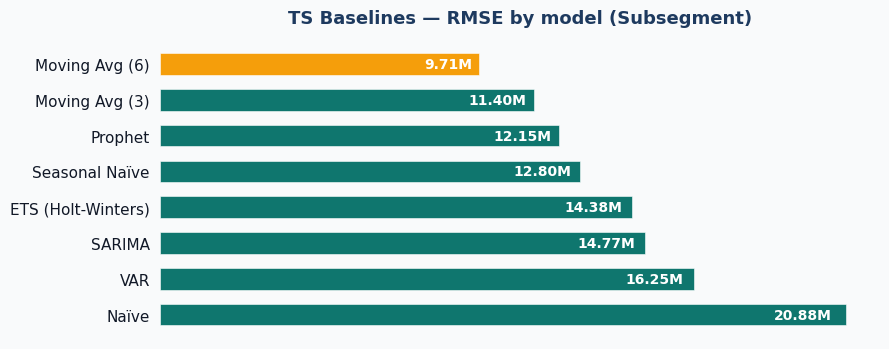

In [21]:
simple_bar(df_baselines, "RMSE", "TS Baselines — RMSE by model (Subsegment)", "#0F766E")


---
## 4. ML — Recursive Forecasting
### Notebook 6a) — Supervised ML with Recursive Engine, all hierarchy levels

ML models trained on 100 engineered features. The recursive engine predicts t+1,
recomputes lag features from that prediction, then predicts t+2, and so on.

> **Note on MinT reconciliation:** A Minimum Trace (MinT) hierarchical reconciliation
> step was prototyped for the recursive approach but could not be fully validated within
> the project timeline. Results below therefore reflect **unreconciled** forecasts — each
> level is trained and evaluated independently. MinT reconciliation is listed as a next step.

**Key findings:**
- At **subsegment level**, Random Forest and LightGBM are the strongest — tree ensembles handle the heterogeneous series better than gradient boosting variants.
- Linear models (Ridge, Lasso, ElasticNet) **collapsed** at subsegment level (wMAPE > 5000%) — they require per-series normalisation to be viable at this granularity.
- At **segment and BU level**, linear models recover and XGBoost performs best.
- **XGBoost was selected as the representative model for this approach** due to its consistent performance across all three hierarchy levels (subsegment, segment, BU), despite not being the top model at any single level. This cross-level stability was the decisive criterion.


In [22]:
for level in ["Subsegment", "Segment", "BU"]:
    df_lv = df_recursive[df_recursive["Level"] == level].copy()
    df_lv = df_lv.drop(columns=["Level"], errors="ignore")
    print(f"\n{'─'*60}\nLevel: {level}\n{'─'*60}")
    display(style_table(df_lv))



────────────────────────────────────────────────────────────
Level: Subsegment
────────────────────────────────────────────────────────────


,Model,RMSE,MAE,wMAPE,R2,Note
★,Random Forest,"12,920,387","7,235,794",19.80%,0.9625,—
,LightGBM,"13,847,374","8,934,442",24.50%,0.9569,—
,XGBoost,"25,332,555","22,247,216",60.90%,0.8559,—
,Gradient Boosting,"25,402,657","21,278,919",58.30%,0.8551,—
,Ridge,"1,977,049,782","1,952,121,726",5346.10%,—,Collapsed (wMAPE > 5000%)
,Lasso,"1,977,065,405","1,952,136,597",5346.10%,—,Collapsed
,ElasticNet,"1,977,146,095","1,952,191,943",5346.30%,—,Collapsed



────────────────────────────────────────────────────────────
Level: Segment
────────────────────────────────────────────────────────────


,Model,RMSE,MAE,wMAPE,R2,Note
,XGBoost,"36,513,280","20,652,000",8.20%,0.9879,—
,Gradient Boosting,"44,076,845","23,389,626",9.20%,0.9824,—
,Lasso,"44,473,927","25,213,573",10.00%,0.9821,—
,LightGBM,"48,201,518","22,096,562",8.70%,0.9790,—
,Ridge,"50,910,221","28,969,801",11.40%,0.9765,—
,ElasticNet,"56,008,064","29,060,447",11.50%,0.9716,—
,Random Forest,"65,257,949","29,486,363",11.60%,0.9614,—



────────────────────────────────────────────────────────────
Level: BU
────────────────────────────────────────────────────────────


,Model,RMSE,MAE,wMAPE,R2,Note
,Lasso,"87,582,300","70,286,400",6.94%,0.9750,—
,LightGBM,"91,523,050","65,737,090",6.49%,0.9727,—
,XGBoost,"97,587,630","73,132,880",7.22%,0.9689,—
,Ridge,"98,203,320","76,586,630",7.56%,0.9685,—
,Gradient Boosting,"100,939,300","74,009,040",7.31%,0.9667,—
,CatBoost,"104,374,000","69,576,780",6.87%,0.9644,—
,Random Forest,"160,465,100","102,917,100",10.16%,0.9160,—
,ElasticNet,"164,552,600","114,345,500",11.29%,0.9116,—


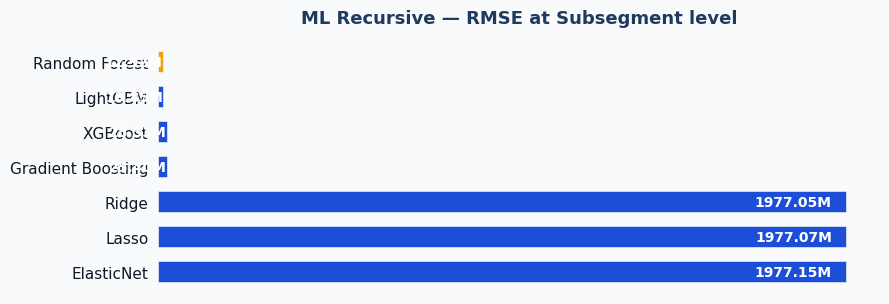

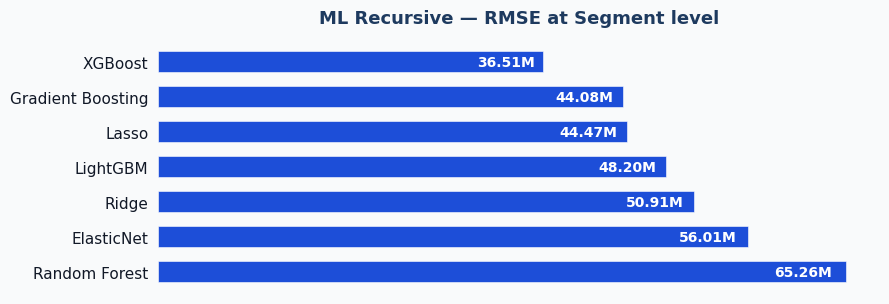

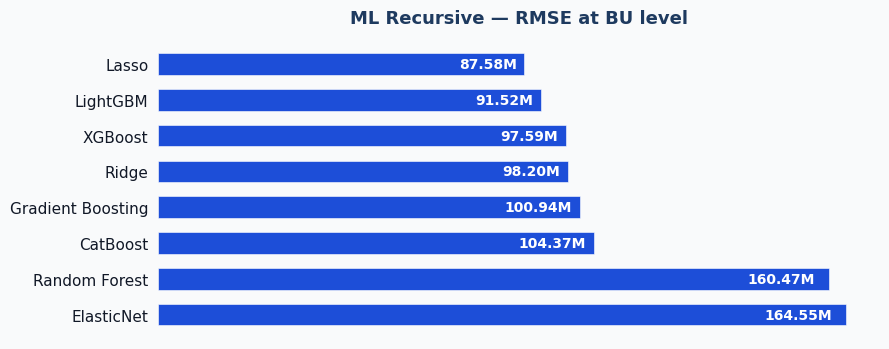

In [23]:
for level in ["Subsegment", "Segment", "BU"]:
    df_lv = df_recursive[(df_recursive["Level"]==level) & df_recursive["RMSE"].notna()].copy()
    simple_bar(df_lv, "RMSE",
               f"ML Recursive — RMSE at {level} level", "#1D4ED8")


---
## 5. ML — Direct Multi-Step Forecasting
### Notebook 6b) — One Model per Horizon h ∈ {1…6}

A separate model is trained for each forecasting horizon h. The target column y(t+h)
is constructed explicitly — no leakage by construction, no accumulated prediction error.

> **Note on MinT reconciliation:** Unlike the recursive approach, the direct multi-step
> framework was successfully integrated with MinT hierarchical reconciliation, producing
> coherent forecasts across subsegment → segment → BU. The results in this section reflect
> the **pre-reconciliation** performance at each level independently.

**Key findings:**
- At **subsegment level**, CatBoost achieves the best raw RMSE (10.27M, wMAPE 14.1%) — a 20% improvement over the best recursive ML model.
- **XGBoost (with Optuna tuning) was selected as the model carried forward to MinT reconciliation and final forecasts.** Although CatBoost has a marginally better RMSE at subsegment level, XGBoost demonstrated superior stability across all three hierarchy levels and was the most consistent performer across the full evaluation framework.
- At **BU level**, Random Forest leads in RMSE (120.5M) but lags at subsegment granularity.


In [24]:
for level in ["Subsegment", "Segment", "BU"]:
    df_lv = df_direct[df_direct["Level"] == level].copy()
    df_lv = df_lv.drop(columns=["Level"], errors="ignore")
    print(f"\n{'─'*60}\nLevel: {level}\n{'─'*60}")
    display(style_table(df_lv))



────────────────────────────────────────────────────────────
Level: Subsegment
────────────────────────────────────────────────────────────


,Model,RMSE,MAE,wMAPE,R2
★,CatBoost,"10,270,056","5,446,644",14.08%,0.9773
,XGBoost,"11,327,380","5,175,391",13.38%,0.9724
,XGBoost (Optuna),"10,739,067",—,12.68%,0.9752
,Ridge (Linear),"11,395,822","6,944,689",17.95%,0.9721
,LightGBM,"12,101,632","5,254,137",13.58%,0.9685
,Random Forest,"13,625,487","5,983,083",15.47%,0.9601



────────────────────────────────────────────────────────────
Level: Segment
────────────────────────────────────────────────────────────


,Model,RMSE,MAE,wMAPE,R2
,XGBoost,"49,490,236","24,165,045",9.54%,0.9778
,LightGBM,"49,838,032","24,154,514",9.54%,0.9775
,Random Forest,"55,322,294","27,585,774",10.89%,0.9723
,CatBoost,"56,108,305","32,878,876",12.98%,0.9715
,Ridge (Linear),"51,675,486","34,826,621",13.75%,0.9758



────────────────────────────────────────────────────────────
Level: BU
────────────────────────────────────────────────────────────


,Model,RMSE,MAE,wMAPE,R2
,Random Forest,"120,543,173","85,704,644",8.46%,0.9526
,Ridge (Linear),"129,282,233","98,402,795",9.71%,0.9455
,XGBoost,"155,083,340","122,453,530",12.09%,0.9215
,LightGBM,"155,727,667","124,084,803",12.25%,0.9209
,CatBoost,"159,241,386","134,501,480",13.28%,0.9172


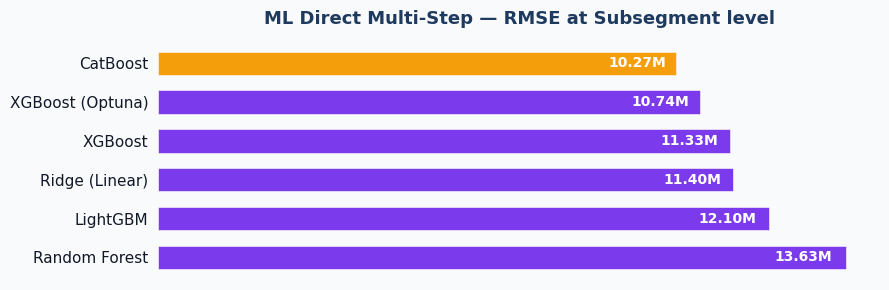

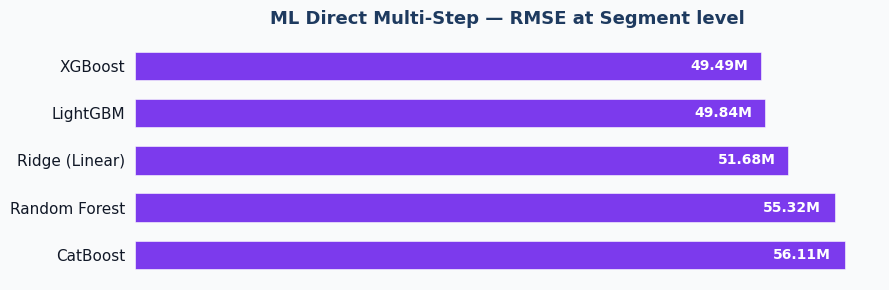

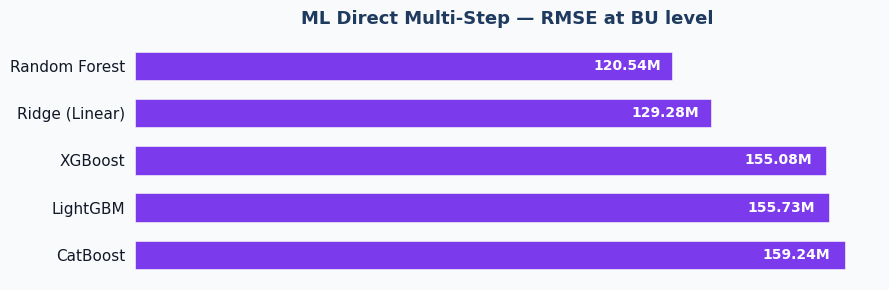

In [25]:
for level in ["Subsegment", "Segment", "BU"]:
    df_lv = df_direct[df_direct["Level"]==level].copy()
    simple_bar(df_lv, "RMSE",
               f"ML Direct Multi-Step — RMSE at {level} level", "#7C3AED")


---
## 6. Foundation Models (Zero-Shot)
### Notebook 6c) — Pre-trained Time Series Foundation Models

Models pre-trained on large corpora of time series data, applied zero-shot without fine-tuning.
They receive only the raw historical Revenue series as input.

**Key finding:** FlowState-r1.1 achieves the **best overall result across all approaches** —
RMSE 7.70M and wMAPE 9.3%, outperforming the Moving Average baseline by **21% on RMSE**.
This is a remarkable result given zero knowledge of our specific data distribution.

> Note: MAE was not recorded for these models.


In [26]:
style_table(df_pretrained)

,Model,RMSE,MAE,wMAPE,R2
★,FlowState-r1.1,"7,743,554","3,663,463",9.40%,0.9871
,Chronos-2,"8,349,869","3,849,745",9.90%,0.9850
,TimesFM-2.5,"9,182,431","4,441,428",11.40%,0.9819


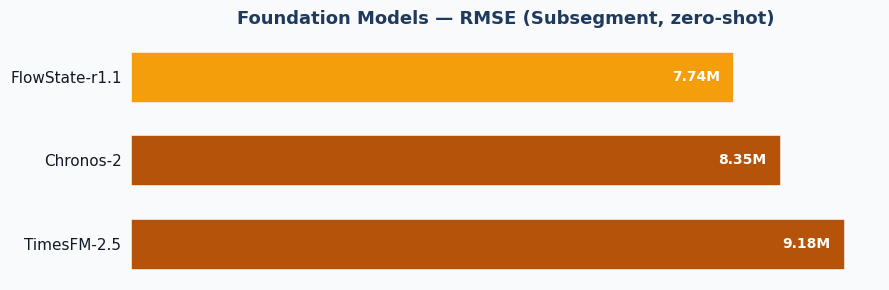

In [27]:
simple_bar(df_pretrained, "RMSE",
           "Foundation Models — RMSE (Subsegment, zero-shot)", "#B45309")


---
## 7. Walk-Forward Validation
### Notebook 6d) — Expanding Window Cross-Validation (6 Folds)

Walk-forward CV trains on all data up to period t, predicts t+1 through t+6,
advances t, and repeats. Results are **averaged across 6 folds**.

This produces more robust and conservative performance estimates than a single split,
as each model is evaluated across multiple temporal windows.

**Key findings:**
- XGBoost achieves the best subsegment RMSE (7.41M), closely followed by LightGBM.
- At segment level XGBoost also leads (RMSE 12.2M, wMAPE 7%).
- At BU level LightGBM edges XGBoost (79.6M vs 79.8M).
- R²≈1.0 for all models is an artefact of the R² calculation within folds — **RMSE and wMAPE are the meaningful metrics here.**


In [28]:
for level in ["Subsegment", "Segment", "BU"]:
    df_lv = df_wf[df_wf["Level"] == level].copy()
    df_lv = df_lv.drop(columns=["Level","R2"], errors="ignore")
    print(f"\n{'─'*60}\nLevel: {level}  (avg across 6 folds)\n{'─'*60}")
    display(style_table(df_lv))



────────────────────────────────────────────────────────────
Level: Subsegment  (avg across 6 folds)
────────────────────────────────────────────────────────────


,Model,RMSE,MAE,wMAPE
★,XGBoost,"7,405,830","3,634,914",10.70%
,LightGBM,"7,650,552","3,479,706",10.30%
,Gradient Boosting,"9,118,630","4,673,275",13.80%
,Random Forest,"9,552,808","4,517,812",13.40%
,Ridge,"10,149,099","6,204,958",18.30%
,Lasso,"10,172,420","6,398,722",18.90%
,ElasticNet,"25,845,811","15,578,352",45.60%



────────────────────────────────────────────────────────────
Level: Segment  (avg across 6 folds)
────────────────────────────────────────────────────────────


,Model,RMSE,MAE,wMAPE
,XGBoost,"26,351,418","12,791,378",6.30%
,Gradient Boosting,"29,500,780","16,366,588",8.00%
,LightGBM,"29,939,074","14,325,608",7.00%
,Ridge,"39,312,172","23,044,018",11.30%
,Lasso,"39,364,003","22,825,999",11.20%
,Random Forest,"40,009,745","20,752,267",10.20%
,ElasticNet,"99,640,653","63,425,194",30.90%



────────────────────────────────────────────────────────────
Level: BU  (avg across 6 folds)
────────────────────────────────────────────────────────────


,Model,RMSE,MAE,wMAPE
,LightGBM,"79,567,159","64,760,391",6.50%
,XGBoost,"79,799,423","60,455,591",6.00%
,Ridge,"88,226,217","72,580,115",7.20%
,Lasso,"89,396,968","72,306,495",7.20%
,Gradient Boosting,"92,325,956","66,874,851",6.60%
,Random Forest,"107,849,478","82,595,137",8.00%
,ElasticNet,"206,984,115","186,006,714",18.10%


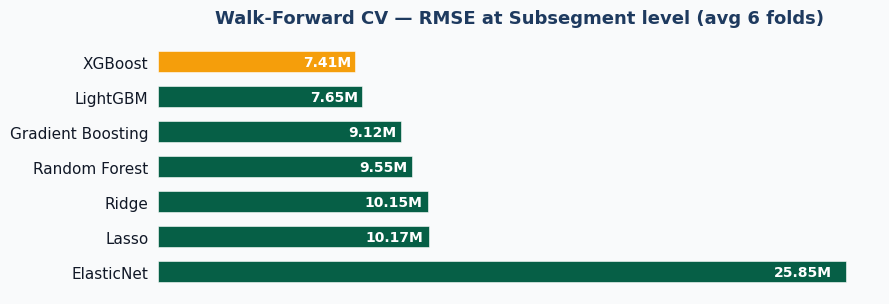

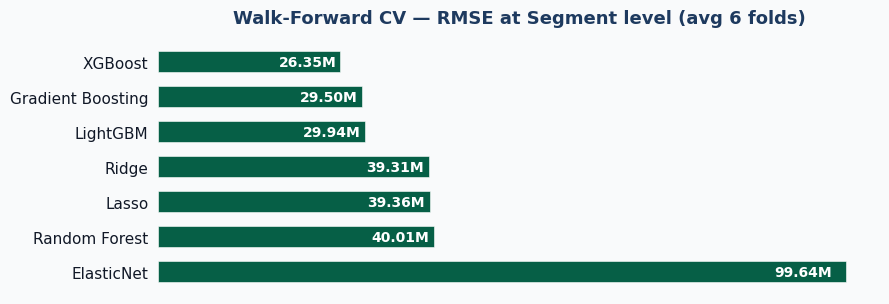

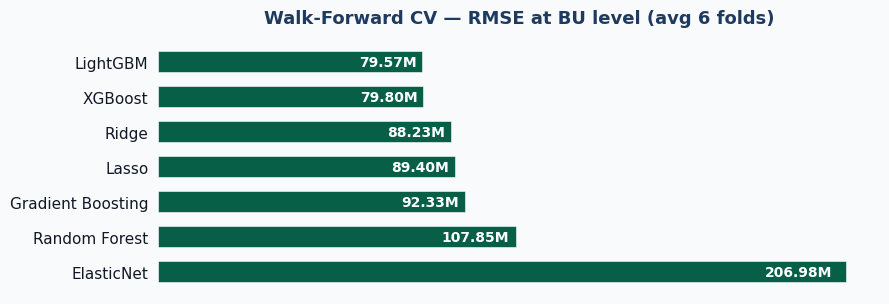

In [29]:
for level in ["Subsegment", "Segment", "BU"]:
    df_lv = df_wf[df_wf["Level"]==level].copy()
    simple_bar(df_lv, "RMSE",
               f"Walk-Forward CV — RMSE at {level} level (avg 6 folds)", "#065F46")


---
## 8. Overall Comparison — Model Selected per Approach

This section consolidates the **model selected to represent each approach**, not necessarily
the one with the lowest RMSE. The selection criterion was **cross-level stability**: the model
that performed most consistently across subsegment, segment, and BU levels was preferred over
one that excelled at a single granularity.

For the ML approaches, XGBoost was the chosen model in both cases because it maintained
competitive performance at every level of the hierarchy — a property critical for a middle-out
forecasting strategy where predictions at multiple levels must be reliable simultaneously.

> Walk-Forward R² is reported as ≈1.0 due to rounding — interpret RMSE and wMAPE only for that row.


In [30]:
df_summary = pd.DataFrame([
    {"Approach": "TS Baselines",         "Best Model": "Moving Avg (6)",    "Notebook": "6a",
     "RMSE": 9_709_532,  "MAE": 4_588_482, "wMAPE": 12.0,  "R2": 0.9796,
     "Selection rationale": "Best RMSE; strong seasonal baseline"},
    {"Approach": "ML Recursive",         "Best Model": "XGBoost",           "Notebook": "6a",
     "RMSE": 25_332_555, "MAE": 22_247_216, "wMAPE": 60.9, "R2": 0.8559,
     "Selection rationale": "Most stable across all 3 levels (subsegment RMSE higher; segment & BU competitive); carried to MinT — not completed within timeline"},
    {"Approach": "ML Direct Multi-Step", "Best Model": "XGBoost (Optuna)",  "Notebook": "6b",
     "RMSE": 10_739_067, "MAE": None,      "wMAPE": 12.68, "R2": 0.9752,
     "Selection rationale": "Most stable across all 3 levels; selected over CatBoost (best subsegment RMSE) for cross-level consistency; used in MinT reconciliation & final forecasts"},
    {"Approach": "Foundation Models",    "Best Model": "FlowState-r1.1",    "Notebook": "6c",
     "RMSE": 7_743_554,  "MAE": 3_663_463, "wMAPE":  9.4,  "R2": 0.9871,
     "Selection rationale": "Best overall zero-shot RMSE; no training required"},
    {"Approach": "Walk-Forward CV",      "Best Model": "XGBoost",           "Notebook": "6d",
     "RMSE": 7_405_830,  "MAE": 3_634_914, "wMAPE": 10.7,  "R2": 0.9866,
     "Selection rationale": "Best avg RMSE across 6 folds; most honest performance estimate"},
])

def highlight_summary(df):
    metric_cols = ["RMSE", "MAE", "wMAPE", "R2"]
    display_df = df[["Approach", "Best Model", "Notebook", "RMSE", "MAE", "wMAPE", "R2", "Selection rationale"]].copy()

    styled = display_df.style.format({
        "RMSE":  "{:,.0f}",
        "MAE":   "{:,.0f}",
        "wMAPE": "{:.2f}%",
        "R2":    "{:.4f}",
    }, na_rep="—")

    for col, best_fn in [("RMSE", min), ("MAE", min), ("wMAPE", min), ("R2", max)]:
        vals = df[col].dropna()
        if vals.empty:
            continue
        best_val = best_fn(vals)
        styled = styled.map(
            lambda v, bv=best_val: (
                "background-color:#d1fae5; font-weight:bold; color:#065f46"
                if v == bv else ""
            ),
            subset=[col]
        )

    styled = styled.set_table_styles([
        {"selector": "th", "props": [
            ("background-color","#1e3a5f"), ("color","white"),
            ("font-size","12px"), ("text-align","center"), ("padding","8px 14px")]},
        {"selector": "td", "props": [
            ("font-size","12px"), ("padding","7px 14px"),
            ("border-bottom","1px solid #e5e7eb")]},
    ]).hide(axis="index")
    return styled

highlight_summary(df_summary)


Approach,Best Model,Notebook,RMSE,MAE,wMAPE,R2,Selection rationale
TS Baselines,Moving Avg (6),6a,"9,709,532","4,588,482",12.00%,0.9796,Best RMSE; strong seasonal baseline
ML Recursive,XGBoost,6a,"25,332,555","22,247,216",60.90%,0.8559,Most stable across all 3 levels (subsegment RMSE higher; segment & BU competitive); carried to MinT — not completed within timeline
ML Direct Multi-Step,XGBoost (Optuna),6b,"10,739,067",—,12.68%,0.9752,Most stable across all 3 levels; selected over CatBoost (best subsegment RMSE) for cross-level consistency; used in MinT reconciliation & final forecasts
Foundation Models,FlowState-r1.1,6c,"7,743,554","3,663,463",9.40%,0.9871,Best overall zero-shot RMSE; no training required
Walk-Forward CV,XGBoost,6d,"7,405,830","3,634,914",10.70%,0.9866,Best avg RMSE across 6 folds; most honest performance estimate


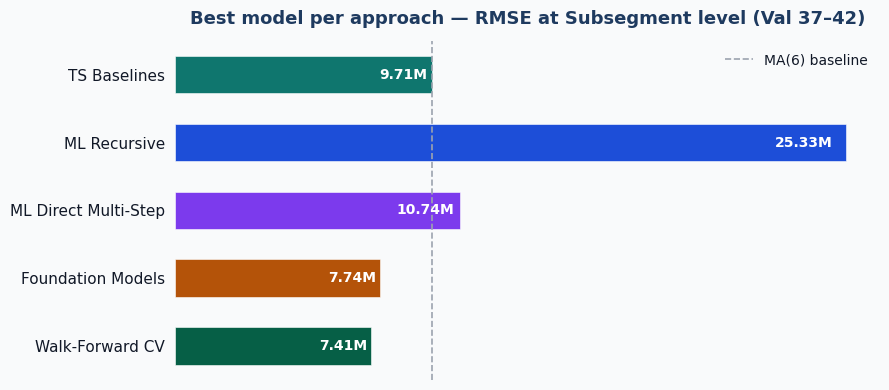

In [31]:
# Summary RMSE bar — one bar per approach, coloured by approach
fig, ax = plt.subplots(figsize=(9, 4))

colors = [APPROACH_COLORS.get(a, "#64748B") for a in df_summary["Approach"]]
bars = ax.barh(df_summary["Approach"], df_summary["RMSE"],
               color=colors, edgecolor="white", linewidth=0.4, height=0.55)

# baseline reference line
baseline = df_summary.loc[df_summary["Approach"]=="TS Baselines", "RMSE"].values[0]
ax.axvline(baseline, color="#9CA3AF", linestyle="--", linewidth=1.2, label="MA(6) baseline")

for bar, val in zip(bars, df_summary["RMSE"]):
    ax.text(bar.get_width() - bar.get_width()*0.02, bar.get_y()+bar.get_height()/2,
            f"{val/1e6:.2f}M", va="center", ha="right", fontsize=10,
            color="white", fontweight="bold")

ax.set_title("Best model per approach — RMSE at Subsegment level (Val 37–42)",
             fontsize=13, fontweight="bold", color="#1e3a5f", pad=12)
ax.invert_yaxis()
ax.set_xlim(right=df_summary["RMSE"].max()*1.05)
ax.spines[["top","right","left","bottom"]].set_visible(False)
ax.tick_params(left=False, bottom=False, labelsize=11, colors="#111827")
ax.set_yticklabels(df_summary["Approach"], fontsize=11, color="#111827")
ax.xaxis.set_visible(False)
ax.grid(False)
ax.legend(fontsize=10, labelcolor="#111827", framealpha=0)
ax.set_facecolor("#F9FAFB")
fig.patch.set_facecolor("#F9FAFB")
plt.tight_layout()
plt.show()

---
## 9. Conclusions & Recommendations

### Summary of findings

| Finding | Detail |
|---|---|
| **Best overall model** | FlowState-r1.1 (zero-shot) — RMSE 7.74M, wMAPE 9.4%, R² 0.9871 |
| **Best supervised ML (Walk-Forward CV)** | XGBoost — RMSE 7.41M averaged across 6 folds; most statistically robust estimate |
| **Best Direct Multi-Step** | CatBoost — RMSE 10.27M at subsegment level; XGBoost selected for final pipeline due to cross-level stability |
| **Strongest baseline** | Moving Average (window=6) — RMSE 9.71M; sets a demanding reference for supervised ML |
| **ML Recursive** | Underperforms direct approach at subsegment level — error accumulation penalises long horizons; MinT reconciliation not completed |
| **Linear models** | Collapsed at subsegment granularity (wMAPE > 5000%); viable only at segment/BU level with regularisation |



### Middle-out hybrid strategy (full framework)

Within the final pipeline, a hybrid assignment rule was applied at subsegment level:

| Subsegment type | Model assigned |
|---|---|
| Predictable, sufficient history | XGBoost Direct Multi-Step + MinT reconciliation |
| Erratic / low-volume | Moving Average (window=6) |
| Dead series (revenue = 0, no orders) | Zero forecast |

### Open items / next steps

- [ ] **MinT for ML Recursive** — hierarchical reconciliation was prototyped but not completed; could close the gap with the direct approach
- [ ] **Foundation model fine-tuning** — FlowState-r1.1 and Chronos-2 show strong zero-shot performance; domain fine-tuning could push accuracy further
- [ ] **Subsegment classifier** — formalise the assignment rule (predictable vs erratic vs dead) with a data-driven threshold rather than manual cutoffs


---
## 10. Export Results

Export all tables to Excel and CSV.

In [32]:
import os

output_dir = "../data/results"
os.makedirs(output_dir, exist_ok=True)

with pd.ExcelWriter(f"{output_dir}/benchmarking_results.xlsx", engine="openpyxl") as writer:
    df_summary.to_excel(writer,    sheet_name="Summary",         index=False)
    df_baselines.to_excel(writer,  sheet_name="6a_Baselines",    index=False)
    df_recursive.to_excel(writer,  sheet_name="6a_ML_Recursive", index=False)
    df_direct.to_excel(writer,     sheet_name="6b_ML_Direct",    index=False)
    df_pretrained.to_excel(writer, sheet_name="6c_Foundation",   index=False)
    df_wf.to_excel(writer,         sheet_name="6d_WalkForward",  index=False)

df_summary.to_csv(f"{output_dir}/benchmarking_summary.csv", index=False)

print(f"✓ Exported to {output_dir}/")
print("  benchmarking_results.xlsx  (6 sheets)")
print("  benchmarking_summary.csv")


✓ Exported to ../data/results/
  benchmarking_results.xlsx  (6 sheets)
  benchmarking_summary.csv
